# Chapter 2 (Hull) — Forward vs. Futures (Section 2.11)

In this continuation of Chapter 2, Hull compares **forward** and **futures** contracts and explains:

1. **Key differences** (Table-style summary)
2. **Profits from forwards vs futures**: same total gain/loss, but **timing differs** (end vs daily settlement)
3. **Foreign exchange quotes**: futures quotes can be expressed differently (USD per unit vs units per USD)

We stay at **Hull Chapter 2 level**: practical mechanics, no advanced pricing.

## 1) Forward vs Futures: key differences (Hull-style)

Both contracts are agreements to buy/sell an asset at a future date for a price fixed today.

### Forward
- **Private OTC contract** between two parties
- **Not standardized**
- Usually **one specific delivery date**
- **Settled at the end** of the contract (cash or delivery)
- **Some credit (counterparty) risk**

### Futures
- **Traded on an exchange**
- **Standardized** contract
- Usually a **range of delivery dates**
- **Settled daily** (mark-to-market)
- Positions are often **closed out before maturity**
- **Virtually no credit risk** (clearing house stands in the middle)

## 2) Profits from forward and futures contracts

Hull’s key point:

- With a **forward**, the profit/loss is realized **only at maturity**.
- With a **futures**, the profit/loss is realized **day by day** via daily settlement (mark-to-market).

If interest rates are assumed constant (simple setting), the **total** profit over the life of the contract
can be very similar, but the **cashflow timing** differs.

Forward profit at maturity: $200,000
Futures total (cum) profit:  $19,754


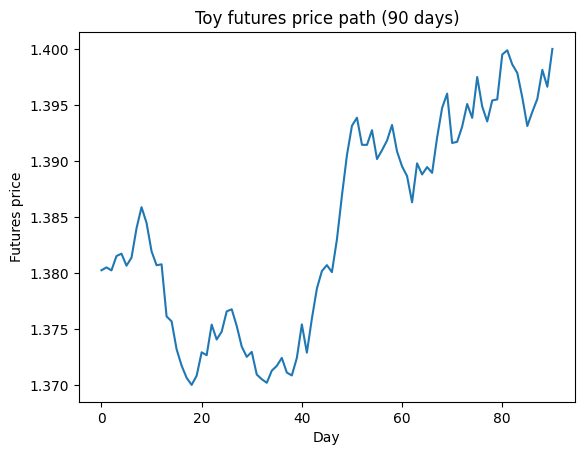

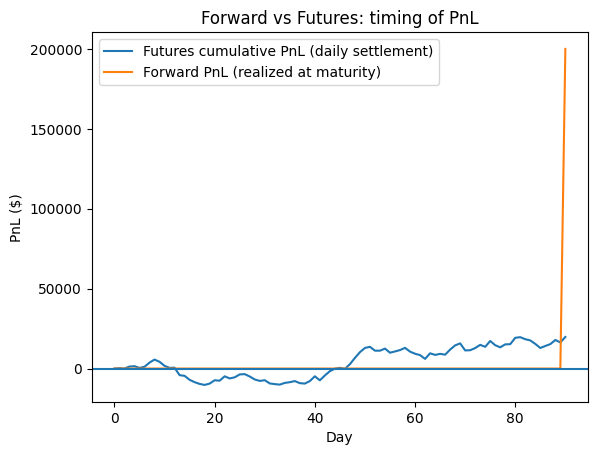

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (toy Hull-style example)
N = 1_000_000        # e.g., 1 million GBP notional
K = 1.2000           # forward delivery price (USD/GBP)
F0 = K               # assume futures starts at same level
n_days = 90

# Create a toy futures price path that ends higher (so total profit > 0)
# We'll create daily noise but force an end level to match a target.
rng = np.random.default_rng(0)

target_ST = 1.4000                  # spot (and futures) at maturity in the Hull example
target_FT = target_ST               # simplify: futures converges to spot near delivery

# Random increments then scale to hit the target at the end
increments = rng.normal(0, 0.002, n_days)
F = np.empty(n_days + 1)
F[0] = F0
F[1:] = F0 + np.cumsum(increments)

# Shift so that F[-1] matches target_FT
F = F + (target_FT - F[-1])

# Forward profit: all at the end
forward_profit_T = (target_ST - K) * N

# Futures daily cashflows and cumulative PnL
dF = np.diff(F)
futures_daily_cf = dF * N
futures_cum_pnl = np.concatenate([[0], np.cumsum(futures_daily_cf)])

print(f"Forward profit at maturity: ${forward_profit_T:,.0f}")
print(f"Futures total (cum) profit:  ${futures_cum_pnl[-1]:,.0f}")

# Plot futures price path
plt.figure()
plt.plot(F)
plt.title("Toy futures price path (90 days)")
plt.xlabel("Day")
plt.ylabel("Futures price")
plt.show()

# Plot futures cumulative PnL vs forward (step at the end)
plt.figure()
plt.plot(futures_cum_pnl, label="Futures cumulative PnL (daily settlement)")

forward_line = np.zeros(n_days + 1)
forward_line[-1] = forward_profit_T
plt.plot(forward_line, label="Forward PnL (realized at maturity)")

plt.title("Forward vs Futures: timing of PnL")
plt.xlabel("Day")
plt.ylabel("PnL ($)")
plt.axhline(0)
plt.legend()
plt.show()